### 1. 도메인 분석 _ Revolving (일부결제금액이월약정)

: 이번 달 카드값을 다 못내면, 일정 비율만 내고 나머지는 다음 달로 넘겨주는 서비스

-> 이월 잔액에 대한 수수로(이자)를 통해 수익을 내는 구조. (이자율이 상당히 높음)

그래서 카드사 입장에서는 이월 잔액이 어느정도 있고, 매월 이자 수준의 금액만 값는 고객들이 수익성 높음

하지만 이월 금액을 갚는 시간이 길어질수록, 약정결제비율을 줄일 수록 고객의 상환 능력에 대한 의심 가능. 

고객이 잔금을 모두 갚는다면 문제가 없지만 값지 못했을 때 카드사에게 생기는 리스크도 상당함.

그래서 카드사는 해당월의 RV관련 데이터를 가지고 다음 달 고객의 잔여금액을 예측하는게 중요함.

if 예측에 성공해서 카드사의 이익에 위험이 될 고객을 먼저 선별할 수 있다면 카드사에서도 미리 대응 가능.

### 2. 데이터 이해 ###

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import glob

pd.set_option('display.max_columns', None)

### <05. 카드 잔액정보 10,11월>

In [4]:
#해당 컬럼이 어느 파일에 위치하는지 확인

target_col = '이용금액_신판_B0M'

for path in glob.glob("data/**/*.csv", recursive=True):
    df_tmp = pd.read_csv(path, nrows=0)   # 헤더만 읽기
    if target_col in df_tmp.columns:
        print(">>> 컬럼 발견:", path)


>>> 컬럼 발견: data\03.카드_승인매출정보\201807_승인매출정보.csv
>>> 컬럼 발견: data\03.카드_승인매출정보\201808_승인매출정보.csv
>>> 컬럼 발견: data\03.카드_승인매출정보\201809_승인매출정보.csv
>>> 컬럼 발견: data\03.카드_승인매출정보\201810_승인매출정보.csv
>>> 컬럼 발견: data\03.카드_승인매출정보\201811_승인매출정보.csv
>>> 컬럼 발견: data\03.카드_승인매출정보\201812_승인매출정보.csv


In [5]:
#df_(파일번호)(해당월) = pd.read_csv('data/01.카드_/201801_.csv')

df_510 = pd.read_csv("data/05.카드_잔액정보/201810_잔액정보.csv")
df_511 = pd.read_csv("data/05.카드_잔액정보/201811_잔액정보.csv")

In [6]:
df_510.head(10)

,기준년월,발급회원번호,잔액_B0M,잔액_일시불_B0M,잔액_할부_B0M,잔액_현금서비스_B0M,잔액_리볼빙일시불이월_B0M,잔액_리볼빙CA이월_B0M,잔액_카드론_B0M,월중평잔_일시불_B0M,월중평잔_할부_B0M,월중평잔_CA_B0M,카드론잔액_최종경과월,연체일자_B0M,연체잔액_B0M,연체잔액_일시불_B0M,연체잔액_할부_B0M,연체잔액_현금서비스_B0M,연체잔액_카드론_B0M,연체잔액_대환론_B0M,잔액_현금서비스_B1M,잔액_현금서비스_B2M,잔액_카드론_B1M,잔액_카드론_B2M,잔액_카드론_B3M,잔액_카드론_B4M,잔액_카드론_B5M,잔액_할부_B1M,잔액_할부_B2M,잔액_일시불_B1M,잔액_일시불_B2M,연체일수_B1M,연체일수_B2M,연체원금_B1M,연체원금_B2M,연체일수_최근,연체원금_최근,최종연체회차,매각잔액_B1M,최종연체개월수_R15M,RV_평균잔액_R12M,RV_최대잔액_R12M,RV_평균잔액_R6M,RV_최대잔액_R6M,RV_평균잔액_R3M,RV_최대잔액_R3M,RV잔액이월횟수_R6M,RV잔액이월횟수_R3M,잔액_할부_유이자_B0M,잔액_할부_무이자_B0M,잔액_할부_해외_B0M,연체잔액_일시불_해외_B0M,연체잔액_RV일시불_B0M,연체잔액_RV일시불_해외_B0M,연체잔액_할부_해외_B0M,연체잔액_CA_B0M,연체잔액_CA_해외_B0M,월중평잔,월중평잔_일시불,월중평잔_RV일시불,월중평잔_할부,월중평잔_CA,월중평잔_카드론,평잔_3M,평잔_일시불_3M,평잔_일시불_해외_3M,평잔_RV일시불_3M,평잔_RV일시불_해외_3M,평잔_할부_3M,평잔_할부_해외_3M,평잔_CA_3M,평잔_CA_해외_3M,평잔_카드론_3M,평잔_6M,평잔_일시불_6M,평잔_일시불_해외_6M,평잔_RV일시불_6M,평잔_RV일시불_해외_6M,평잔_할부_6M,평잔_할부_해외_6M,평잔_CA_6M,평잔_CA_해외_6M,평잔_카드론_6M
0,201810,SYN_0,2597681,70554,90305,2436822,0,0,0,85740,55449,2790307,0,NaN,0,0,0,0,0,0,3094913,3082854,0,0,0,0,0,60412,62455,60714,69766,-99999999,-99999999,0,0,-99999999,0,0,0,0,0,0,0,0,0,0,0,0,0,90305,0,0,0,0,0,0,0,1745094,103509,0,53953,2706793,0,2391893,158213,0,0,0,56574,0,2544537,0,0,2557575,256292,0,0,0,59384,0,2026810,0,0
1,201810,SYN_1,436830,266955,169875,0,0,0,0,257738,177333,0,0,NaN,0,0,0,0,0,0,0,0,0,0,0,0,0,183001,214363,256593,313892,-99999999,-99999999,0,0,-99999999,0,0,0,0,0,0,0,0,0,0,0,0,169875,0,0,0,0,0,0,0,0,544499,299553,249487,169974,0,0,535682,329315,0,264165,0,237061,0,0,0,0,679469,294516,0,277699,0,222705,0,0,0,0
2,201810,SYN_2,0,0,0,0,0,0,0,0,0,0,0,NaN,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,-99999999,-99999999,0,0,-99999999,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,67743,54752,0,0,0,0,0,0,0,0
3,201810,SYN_3,34286,34286,0,0,0,0,0,30485,0,0,0,NaN,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,29066,25058,-99999999,-99999999,0,0,-99999999,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,19734,20758,96232,0,0,0,17853,18797,0,88596,0,0,0,0,0,0,18633,19233,0,87912,0,0,0,0,0,0
4,201810,SYN_4,0,0,0,0,0,0,0,0,0,0,0,NaN,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,-99999999,-99999999,0,0,-99999999,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
5,201810,SYN_5,0,0,0,0,0,0,0,0,0,0,0,NaN,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,-99999999,-99999999,0,0,-99999999,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
6,201810,SYN_6,0,0,0,0,0,0,0,0,0,0,0,NaN,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,-99999999,-99999999,0,0,-99999999,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
7,201810,SYN_7,206644,0,206644,0,0,0,0,0,158586,0,0,NaN,0,0,0,0,0,0,0,0,0,0,0,0,0,144670,157343,0,0,-99999999,-99999999,0,0,-99999999,0,-9999,0,0,0,0,0,0,0,0,0,0,0,206644,0,0,0,0,0,0,0,314478,0,0,134015,0,0,504081,0,0,0,0,153264,0,0,0,0,683515,0,0,0,0,234420,0,0,0,0
8,201810,SYN_8,887996,887996,0,0,0,0,0,1490336,0,0,0,NaN,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,997338,1014729,0,0,0,0,-99999999,0,-9999,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,867859,1588757,0,0,0,0,759538,1375396,30548,0,0,58573,0,0,0,0,988460,1253866,28673,0,0,137510,0,0,0,0
9,201810,SYN_9,112253,112253,0,0,0,0,0,125523,0,0,0,NaN,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,125893,118683,-99999999,-99999999,0,0,-99999999,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,132809,130650,0,0,0,0,123102,119783,0,0,0,0,0,0,0,0,133079,116937,0,0,0,0,0,0,0,0


In [7]:
df_510.columns

Index(['기준년월', '발급회원번호', '잔액_B0M', '잔액_일시불_B0M', '잔액_할부_B0M', '잔액_현금서비스_B0M',
       '잔액_리볼빙일시불이월_B0M', '잔액_리볼빙CA이월_B0M', '잔액_카드론_B0M', '월중평잔_일시불_B0M',
       '월중평잔_할부_B0M', '월중평잔_CA_B0M', '카드론잔액_최종경과월', '연체일자_B0M', '연체잔액_B0M',
       '연체잔액_일시불_B0M', '연체잔액_할부_B0M', '연체잔액_현금서비스_B0M', '연체잔액_카드론_B0M',
       '연체잔액_대환론_B0M', '잔액_현금서비스_B1M', '잔액_현금서비스_B2M', '잔액_카드론_B1M',
       '잔액_카드론_B2M', '잔액_카드론_B3M', '잔액_카드론_B4M', '잔액_카드론_B5M', '잔액_할부_B1M',
       '잔액_할부_B2M', '잔액_일시불_B1M', '잔액_일시불_B2M', '연체일수_B1M', '연체일수_B2M',
       '연체원금_B1M', '연체원금_B2M', '연체일수_최근', '연체원금_최근', '최종연체회차', '매각잔액_B1M',
       '최종연체개월수_R15M', 'RV_평균잔액_R12M', 'RV_최대잔액_R12M', 'RV_평균잔액_R6M',
       'RV_최대잔액_R6M', 'RV_평균잔액_R3M', 'RV_최대잔액_R3M', 'RV잔액이월횟수_R6M',
       'RV잔액이월횟수_R3M', '잔액_할부_유이자_B0M', '잔액_할부_무이자_B0M', '잔액_할부_해외_B0M',
       '연체잔액_일시불_해외_B0M', '연체잔액_RV일시불_B0M', '연체잔액_RV일시불_해외_B0M',
       '연체잔액_할부_해외_B0M', '연체잔액_CA_B0M', '연체잔액_CA_해외_B0M', '월중평잔', '월중평잔_일시불',
       '월중평잔_RV일시불', '월중평잔_할부', '월중평잔_CA', '월중평잔_카드론',

In [8]:
df_510_rv=df_510.loc[df_510['잔액_리볼빙일시불이월_B0M']>0]

In [9]:
df_510_rv.head(10)

,기준년월,발급회원번호,잔액_B0M,잔액_일시불_B0M,잔액_할부_B0M,잔액_현금서비스_B0M,잔액_리볼빙일시불이월_B0M,잔액_리볼빙CA이월_B0M,잔액_카드론_B0M,월중평잔_일시불_B0M,월중평잔_할부_B0M,월중평잔_CA_B0M,카드론잔액_최종경과월,연체일자_B0M,연체잔액_B0M,연체잔액_일시불_B0M,연체잔액_할부_B0M,연체잔액_현금서비스_B0M,연체잔액_카드론_B0M,연체잔액_대환론_B0M,잔액_현금서비스_B1M,잔액_현금서비스_B2M,잔액_카드론_B1M,잔액_카드론_B2M,잔액_카드론_B3M,잔액_카드론_B4M,잔액_카드론_B5M,잔액_할부_B1M,잔액_할부_B2M,잔액_일시불_B1M,잔액_일시불_B2M,연체일수_B1M,연체일수_B2M,연체원금_B1M,연체원금_B2M,연체일수_최근,연체원금_최근,최종연체회차,매각잔액_B1M,최종연체개월수_R15M,RV_평균잔액_R12M,RV_최대잔액_R12M,RV_평균잔액_R6M,RV_최대잔액_R6M,RV_평균잔액_R3M,RV_최대잔액_R3M,RV잔액이월횟수_R6M,RV잔액이월횟수_R3M,잔액_할부_유이자_B0M,잔액_할부_무이자_B0M,잔액_할부_해외_B0M,연체잔액_일시불_해외_B0M,연체잔액_RV일시불_B0M,연체잔액_RV일시불_해외_B0M,연체잔액_할부_해외_B0M,연체잔액_CA_B0M,연체잔액_CA_해외_B0M,월중평잔,월중평잔_일시불,월중평잔_RV일시불,월중평잔_할부,월중평잔_CA,월중평잔_카드론,평잔_3M,평잔_일시불_3M,평잔_일시불_해외_3M,평잔_RV일시불_3M,평잔_RV일시불_해외_3M,평잔_할부_3M,평잔_할부_해외_3M,평잔_CA_3M,평잔_CA_해외_3M,평잔_카드론_3M,평잔_6M,평잔_일시불_6M,평잔_일시불_해외_6M,평잔_RV일시불_6M,평잔_RV일시불_해외_6M,평잔_할부_6M,평잔_할부_해외_6M,평잔_CA_6M,평잔_CA_해외_6M,평잔_카드론_6M
108,201810,SYN_108,6148994,2292379,0,1188442,1512611,0,1155562,2541927,0,1011422,0,NaN,0,0,0,0,0,0,1234810,1194247,1047618,1081465,1122353,1226792,1188291,0,70636,2866610,2698949,-99999999,-99999999,0,0,-99999999,0,-9999,0,0,2249140,2964268,1739689,2056324,1770436,2056324,6,3,0,0,0,0,0,0,0,0,0,3204525,2431626,3709992,0,998823,900550,3682014,2245452,72888,4062640,58076,25883,0,1152834,0,541263,4940327,2061847,78168,4218579,53705,44603,0,1498130,0,675511
116,201810,SYN_116,2378072,1238731,0,0,1139341,0,0,1273831,0,804283,0,NaN,0,0,0,0,0,0,1099625,1128872,0,0,0,0,0,0,0,1419666,1559766,86,86,436871,535951,99,449847,-9999,0,3,1529022,2175153,1150024,1310550,1162321,1265760,6,3,0,0,0,0,0,0,0,0,0,1499231,1117335,1481292,0,868351,0,2607103,1190321,0,1464088,0,43060,0,722587,0,0,6654760,1821247,0,1856864,0,132798,0,779546,0,0
130,201810,SYN_130,10621291,3020335,371042,916661,1936044,2631417,1745792,2887384,185617,698460,0,NaN,0,0,0,0,0,0,883489,851215,1684909,1712524,1729359,1958451,2402622,191333,230682,3338609,3599158,-99999999,-99999999,0,0,-99999999,0,-9999,0,0,3803153,3772276,2737139,2933212,2796448,2933212,6,3,244328,126714,0,0,0,0,0,0,0,10129764,2735060,3292995,183344,676758,1549500,11103541,2736418,0,3947971,0,205780,0,680114,0,1381643,10846977,2344965,0,4061546,0,322658,0,749227,0,1644468
214,201810,SYN_214,10380384,819989,0,912991,894886,0,7752518,1302398,0,709530,0,NaN,0,0,0,0,0,0,847714,871530,9201681,9122325,8969051,8746611,10952923,0,0,949270,973286,0,0,0,0,-99999999,0,0,0,0,317252,890150,462790,809432,521198,809432,6,3,0,0,0,0,0,0,0,0,0,14950789,1158498,1621869,0,677342,9067277,21673218,1949992,0,2039534,0,32262,0,723535,0,12338518,28573276,2168589,0,2125363,0,109229,0,898783,0,14149992
227,201810,SYN_227,4914003,1644127,461325,1784148,1024403,0,0,2675803,206863,1938063,0,NaN,0,0,0,0,0,0,2029185,2007982,0,0,0,0,0,203157,217155,1668890,1520834,0,0,0,0,-99999999,0,0,0,2,831746,1541686,711455,1120249,826032,1120249,6,3,322735,138590,0,0,0,0,0,0,0,4915124,2077043,1470200,206157,1963178,0,4774080,2087627,0,1535652,0,241830,0,2527494,0,0,4485883,2030416,0,1617071,0,366533,0,2678335,0,0
233,201810,SYN_233,4855483,2587211,1016740,0,1251532,0,0,2351865,1332811,0,0,NaN,0,0,0,0,0,0,0,0,0,0,0,0,0,1305417,1579933,3033240,2825278,-99999999,-99999999,0,0,-99999999,0,0,0,0,1000992,1889368,981156,1523516,1096798,1523516,6,3,727322,289418,0,0,0,0,0,0,0,2847432,2011788,3049948,1338176,0,0,2494921,1715355,43394,3242141,42976,1300754,0,0,0,0,4056413,1539102,43803,3420941,39464,1629786,0,77897,0,765637
263,201810,SYN_263,5158080,2940400,422012,0,1795668,0,0,3546669,477367,631230,0,NaN,0,0,0,0,0,0,0,0,0,0,0,0,0,459606,570223,2680894,2578602,-99999999,-99999999,0,0,-99999999,0,0,0,0,2823157,3629018,2164155,2414084,2180585,2275953,6,3,0,422012,0,0,0,0,0,0,0,5117963,3496726,4175700,481112,606298,0,6016258,4293998,46686,4874880,50912,525590,0,411581,0,0,6679712,4512736,46735,4797887,44426,549604,0,319157,0,0
297,201810,SYN_297,5798430,2064690,0,0,2140721,0,1593019,2414143,0,0,0,NaN,0,0,0,0,0,0,0,0,1476199,1461189,1534581,1551391,16548

In [10]:
df_goal_10=df_510_rv.loc[df_510['연체잔액_RV일시불_B0M']>0]

In [11]:
df_goal_10.head(10)

,기준년월,발급회원번호,잔액_B0M,잔액_일시불_B0M,잔액_할부_B0M,잔액_현금서비스_B0M,잔액_리볼빙일시불이월_B0M,잔액_리볼빙CA이월_B0M,잔액_카드론_B0M,월중평잔_일시불_B0M,월중평잔_할부_B0M,월중평잔_CA_B0M,카드론잔액_최종경과월,연체일자_B0M,연체잔액_B0M,연체잔액_일시불_B0M,연체잔액_할부_B0M,연체잔액_현금서비스_B0M,연체잔액_카드론_B0M,연체잔액_대환론_B0M,잔액_현금서비스_B1M,잔액_현금서비스_B2M,잔액_카드론_B1M,잔액_카드론_B2M,잔액_카드론_B3M,잔액_카드론_B4M,잔액_카드론_B5M,잔액_할부_B1M,잔액_할부_B2M,잔액_일시불_B1M,잔액_일시불_B2M,연체일수_B1M,연체일수_B2M,연체원금_B1M,연체원금_B2M,연체일수_최근,연체원금_최근,최종연체회차,매각잔액_B1M,최종연체개월수_R15M,RV_평균잔액_R12M,RV_최대잔액_R12M,RV_평균잔액_R6M,RV_최대잔액_R6M,RV_평균잔액_R3M,RV_최대잔액_R3M,RV잔액이월횟수_R6M,RV잔액이월횟수_R3M,잔액_할부_유이자_B0M,잔액_할부_무이자_B0M,잔액_할부_해외_B0M,연체잔액_일시불_해외_B0M,연체잔액_RV일시불_B0M,연체잔액_RV일시불_해외_B0M,연체잔액_할부_해외_B0M,연체잔액_CA_B0M,연체잔액_CA_해외_B0M,월중평잔,월중평잔_일시불,월중평잔_RV일시불,월중평잔_할부,월중평잔_CA,월중평잔_카드론,평잔_3M,평잔_일시불_3M,평잔_일시불_해외_3M,평잔_RV일시불_3M,평잔_RV일시불_해외_3M,평잔_할부_3M,평잔_할부_해외_3M,평잔_CA_3M,평잔_CA_해외_3M,평잔_카드론_3M,평잔_6M,평잔_일시불_6M,평잔_일시불_해외_6M,평잔_RV일시불_6M,평잔_RV일시불_해외_6M,평잔_할부_6M,평잔_할부_해외_6M,평잔_CA_6M,평잔_CA_해외_6M,평잔_카드론_6M
1099911,201810,SYN_1099911,5645916,698323,214646,1209613,1147997,0,2375337,726513,133692,899495,0,20180723.0,391559,139198,252361,0,0,0,1058810,1119932,2151668,2229802,2663411,2633965,2690632,153764,228751,653820,610632,88,75,1065937,766173,104,871318,-9999,0,2,2137862,2139817,1362881,1568374,1383329,1557033,6,3,214646,0,0,0,118996,0,0,800476,0,4840212,770980,1065722,130644,944295,1987232,13595292,2208761,0,1417740,0,134587,0,551858,0,1968529,16687958,2556097,0,1472530,0,225914,0,580762,0,2229639
1345637,201810,SYN_1345637,2223619,401798,109369,1047443,665009,0,0,514908,108102,915041,0,20180725.0,2054839,137274,272019,1645546,0,0,1027923,1073042,0,0,0,0,0,99938,113870,430440,415526,84,72,882790,814393,102,942049,0,0,2,419842,888877,708777,1135960,562915,811938,6,3,0,109369,0,0,108462,0,0,812136,0,1286138,831467,772029,94511,839728,0,1904149,1231069,0,900474,0,101447,0,812436,0,0,1861388,1271041,0,808872,0,108923,0,806988,0,0
2016603,201810,SYN_2016603,506670,52116,0,0,454554,0,0,39455,0,0,0,20180718.0,84499,84499,0,0,0,0,0,0,0,0,0,0,0,0,0,19200,29550,90,84,222100,248153,100,334860,-9999,0,4,183809,395909,231661,441896,274427,441896,6,3,0,0,0,0,92181,0,0,0,0,197316,34385,165657,0,0,0,84964,25175,0,85664,0,0,0,0,0,0,24976,21016,0,230065,0,0,0,0,0,0
2316993,201810,SYN_2316993,1835472,747058,274922,0,813492,0,0,746711,273872,0,0,20180723.0,411163,146726,264437,0,0,0,0,0,0,0,0,0,0,321138,364804,774094,1219780,92,78,1201666,1051283,106,905551,-9999,0,2,669194,1176676,896556,1278933,770096,949727,6,3,274922,0,0,0,106519,0,0,0,0,873647,787224,1043702,240614,0,0,1161960,930551,0,1147679,0,239702,0,0,0,0,1311205,1643515,0,1113011,0,215517,0,0,0,0
2458561,201810,SYN_2458561,4878537,190763,1211701,881887,491019,0,2103167,211776,2050675,736470,0,20180721.0,2098141,154923,288869,1654349,0,0,982443,827833,1882847,2204824,2140270,2217116,2133126,2077212,2312877,255444,265495,91,76,1323780,1132082,105,1196557,-9999,0,2,112348,404807,283408,489027,273478,457079,6,3,883926,327775,0,0,111628,0,0,792609,0,4660904,255596,328661,1997373,773433,1649594,10384971,420814,0,397709,0,2505588,0,613051,0,1256105,7639478,389930,0,379495,0,2589441,0,534499,0,1251452
2826036,201810,SYN_2826036,6086256,471141,429902,0,738051,0,4447162,470341,299639,0,0,20180804.0,326936,94193,232743,0,0,0,0,0,4071066,6426184,5767269,4832926,6520046,296020,240128,408794,607951,83,69,615515,435995,91,576228,-9999,0,2,931717,1190887,958064,1395369,889793,1395369,6,3,429902,0,0,0,89094,0,0,0,0,4846332,425880,697849,296711,0,4067080,9548983,591381,0,799510,0,245348,0,0,0,4981598,13563473,956720,0,999211,0,321153,0,0,0,4207766


<잔액 관계 파악>

잔액_B0M = 잔액_일시불_B0M + 잔액_할부_B0M + 잔액_현금서비스_B0M + 잔액_리볼빙일시불이월_B0M + 잔액_리볼빙CA이월_B0M + 잔액_카드론_B0M

즉, 잔액 = (일시불, 할부, 현금서비스)의 잔액 + (RV 일시불, 카드론(할부), CA(현금서비스) 이월의 잔액)

In [12]:
#108 인덱스 예시 SYN_108

2292379	+ 1188442 + 1512611	+1155562

6148994

### <02. 카드 신용정보 10월>

In [15]:
#해당 컬럼이 어느 파일에 위치하는지 확인

target_col = 'RV약정청구율'

for path in glob.glob("data/**/*.csv", recursive=True):
    df_tmp = pd.read_csv(path, nrows=0)   # 헤더만 읽기
    if target_col in df_tmp.columns:
        print(">>> 컬럼 발견:", path)


>>> 컬럼 발견: data\02.카드_신용정보\201807_신용정보.csv
>>> 컬럼 발견: data\02.카드_신용정보\201808_신용정보.csv
>>> 컬럼 발견: data\02.카드_신용정보\201809_신용정보.csv
>>> 컬럼 발견: data\02.카드_신용정보\201810_신용정보.csv
>>> 컬럼 발견: data\02.카드_신용정보\201811_신용정보.csv
>>> 컬럼 발견: data\02.카드_신용정보\201812_신용정보.csv


In [51]:
df_210 = pd.read_csv("data/02.카드_신용정보/201810_신용정보.csv")

In [17]:
df_210.head(20)

,기준년월,발급회원번호,최초한도금액,카드이용한도금액,CA한도금액,일시상환론한도금액,월상환론한도금액,CA이자율_할인전,CL이자율_할인전,RV일시불이자율_할인전,RV현금서비스이자율_할인전,RV신청일자,RV약정청구율,RV최소결제비율,자발한도감액횟수_R12M,자발한도감액금액_R12M,자발한도감액후경과월,강제한도감액횟수_R12M,강제한도감액금액_R12M,강제한도감액후경과월,한도증액횟수_R12M,한도증액금액_R12M,한도증액후경과월,상향가능한도금액,상향가능CA한도금액,카드론동의여부,월상환론상향가능한도금액,RV전환가능여부,일시불ONLY전환가능여부,카드이용한도금액_B1M,카드이용한도금액_B2M,특별한도보유여부_R3M,연체감액여부_R3M,한도심사요청건수,한도요청거절건수,한도심사요청후경과월,한도심사거절후경과월,시장단기연체여부_R6M,시장단기연체여부_R3M,시장연체상환여부_R6M,시장연체상환여부_R3M,rv최초시작후경과일
0,201810,SYN_0,0,1972423,599079,0,0,22.995367,18.481231,18.121378,21.209174,NaN,0.0,20.0,0,0,12,0,0,12,0,0,12,0,0,Y,0,N,0,2070408,2075704,0,0,0,0,3,3,0,0,0,0,99999999
1,201810,SYN_1,0,999723,464325,4221427,9229256,14.809273,15.522893,10.793094,13.647785,20180112.0,100.0,10.0,0,0,12,0,0,12,0,0,12,371,121,Y,0,Z,1,1000149,1000085,0,0,0,0,3,3,0,0,0,0,322
2,201810,SYN_2,0,8655018,3059575,4800311,15572993,14.220632,10.899203,10.250000,13.085033,NaN,0.0,10.0,0,0,12,0,0,12,0,0,12,880,281,Y,0,Z,1,7727738,7804117,0,0,0,0,3,3,0,0,0,0,99999999
3,201810,SYN_3,999660,4104654,1483412,8999929,20603515,14.859290,14.856574,10.754823,13.651370,20120428.0,100.0,10.0,0,0,12,0,0,12,0,0,12,629,198,Y,0,Z,1,3622045,3613087,0,0,0,0,3,3,0,0,0,0,2382
4,201810,SYN_4,0,486364,1115581,0,0,14.650908,14.852579,10.408639,13.282264,20120422.0,100.0,10.0,0,0,12,1,202,11,0,0,12,398,143,Y,0,N,0,483746,484206,0,0,0,0,3,3,0,0,0,0,2385
5,201810,SYN_5,0,1000156,411045,0,0,14.220039,10.899979,10.404380,13.128339,NaN,0.0,10.0,0,0,12,0,0,12,0,0,12,429,146,N,1800,Z,1,1000187,1000126,0,0,0,0,3,3,0,0,0,0,99999999
6,201810,SYN_6,0,1000294,409992,0,0,15.131109,15.301145,11.213625,14.461869,NaN,0.0,15.0,0,0,12,1,200,11,0,0,12,0,0,N,474,Z,1,1000226,1000204,0,0,0,0,3,3,0,0,0,0,99999999
7,201810,SYN_7,0,5376544,2668320,0,0,14.645264,14.837803,10.250000,13.294383,NaN,0.0,10.0,0,0,12,0,0,12,0,0,12,930,284,N,1800,Z,1,6901600,6862900,0,0,0,0,3,3,0,0,0,0,99999999
8,201810,SYN_8,0,4970735,1687002,4800070,15844102,14.874616,15.539579,10.892363,13.648088,NaN,0.0,10.0,0,0,12,0,0,12,1,188,6,574,197,Y,0,Z,1,5000272,5000305,0,0,0,0,3,3,0,0,0,0,99999999
9,201810,SYN_9,0,3000285,1187458,0,0,16.961894,16.290141,13.034490,16.219820,NaN,0.0,20.0,0,0,12,0,0,12,0,0,12,537,166,Y,0,Z,1,3000081,2999975,0,0,0,0,3,3,0,0,0,0,99999999


### <03. 승인매출 정보>

In [18]:
#해당 컬럼이 어느 파일에 위치하는지 확인

target_col = '이용금액_신판_B0M'

for path in glob.glob("data/**/*.csv", recursive=True):
    df_tmp = pd.read_csv(path, nrows=0)   # 헤더만 읽기
    if target_col in df_tmp.columns:
        print(">>> 컬럼 발견:", path)


>>> 컬럼 발견: data\03.카드_승인매출정보\201807_승인매출정보.csv
>>> 컬럼 발견: data\03.카드_승인매출정보\201808_승인매출정보.csv
>>> 컬럼 발견: data\03.카드_승인매출정보\201809_승인매출정보.csv
>>> 컬럼 발견: data\03.카드_승인매출정보\201810_승인매출정보.csv
>>> 컬럼 발견: data\03.카드_승인매출정보\201811_승인매출정보.csv
>>> 컬럼 발견: data\03.카드_승인매출정보\201812_승인매출정보.csv


In [19]:
df_310 = pd.read_csv("data/03.카드_승인매출정보/201810_승인매출정보.csv")

In [20]:
df_310.head()

,기준년월,발급회원번호,최종이용일자_기본,최종이용일자_신판,최종이용일자_CA,최종이용일자_카드론,최종이용일자_체크,최종이용일자_일시불,최종이용일자_할부,이용건수_신용_B0M,이용건수_신판_B0M,이용건수_일시불_B0M,이용건수_할부_B0M,이용건수_할부_유이자_B0M,이용건수_할부_무이자_B0M,이용건수_부분무이자_B0M,이용건수_CA_B0M,이용건수_체크_B0M,이용건수_카드론_B0M,이용금액_신용_B0M,이용금액_신판_B0M,이용금액_일시불_B0M,이용금액_할부_B0M,이용금액_할부_유이자_B0M,이용금액_할부_무이자_B0M,이용금액_부분무이자_B0M,이용금액_CA_B0M,이용금액_체크_B0M,이용금액_카드론_B0M,이용후경과월_신용,이용후경과월_신판,이용후경과월_일시불,이용후경과월_할부,이용후경과월_할부_유이자,이용후경과월_할부_무이자,이용후경과월_부분무이자,이용후경과월_CA,이용후경과월_체크,이용후경과월_카드론,이용건수_신용_R12M,이용건수_신판_R12M,이용건수_일시불_R12M,이용건수_할부_R12M,이용건수_할부_유이자_R12M,이용건수_할부_무이자_R12M,이용건수_부분무이자_R12M,이용건수_CA_R12M,이용건수_체크_R12M,이용건수_카드론_R12M,이용금액_신용_R12M,이용금액_신판_R12M,이용금액_일시불_R12M,이용금액_할부_R12M,이용금액_할부_유이자_R12M,이용금액_할부_무이자_R12M,이용금액_부분무이자_R12M,이용금액_CA_R12M,이용금액_체크_R12M,이용금액_카드론_R12M,최대이용금액_신용_R12M,최대이용금액_신판_R12M,최대이용금액_일시불_R12M,최대이용금액_할부_R12M,최대이용금액_할부_유이자_R12M,최대이용금액_할부_무이자_R12M,최대이용금액_부분무이자_R12M,최대이용금액_CA_R12M,최대이용금액_체크_R12M,최대이용금액_카드론_R12M,이용개월수_신용_R12M,이용개월수_신판_R12M,이용개월수_일시불_R12M,이용개월수_할부_R12M,이용개월수_할부_유이자_R12M,이용개월수_할부_무이자_R12M,이용개월수_부분무이자_R12M,이용개월수_CA_R12M,이용개월수_체크_R12M,이용개월수_카드론_R12M,이용건수_신용_R6M,이용건수_신판_R6M,이용건수_일시불_R6M,이용건수_할부_R6M,이용건수_할부_유이자_R6M,이용건수_할부_무이자_R6M,이용건수_부분무이자_R6M,이용건수_CA_R6M,이용건수_체크_R6M,이용건수_카드론_R6M,이용금액_신용_R6M,이용금액_신판_R6M,이용금액_일시불_R6M,이용금액_할부_R6M,이용금액_할부_유이자_R6M,이용금액_할부_무이자_R6M,이용금액_부분무이자_R6M,이용금액_CA_R6M,이용금액_체크_R6M,이용금액_카드론_R6M,이용개월수_신용_R6M,이용개월수_신판_R6M,이용개월수_일시불_R6M,이용개월수_할부_R6M,이용개월수_할부_유이자_R6M,이용개월수_할부_무이자_R6M,이용개월수_부분무이자_R6M,이용개월수_CA_R6M,이용개월수_체크_R6M,이용개월수_카드론_R6M,이용건수_신용_R3M,이용건수_신판_R3M,이용건수_일시불_R3M,이용건수_할부_R3M,이용건수_할부_유이자_R3M,이용건수_할부_무이자_R3M,이용건수_부분무이자_R3M,이용건수_CA_R3M,이용건수_체크_R3M,이용건수_카드론_R3M,이용금액_신용_R3M,이용금액_신판_R3M,이용금액_일시불_R3M,이용금액_할부_R3M,이용금액_할부_유이자_R3M,이용금액_할부_무이자_R3M,이용금액_부분무이자_R3M,이용금액_CA_R3M,이용금액_체크_R3M,이용금액_카드론_R3M,이용개월수_신용_R3M,이용개월수_신판_R3M,이용개월수_일시불_R3M,이용개월수_할부_R3M,이용개월수_할부_유이자_R3M,이용개월수_할부_무이자_R3M,이용개월수_부분무이자_R3M,이용개월수_CA_R3M,이용개월수_체크_R3M,이용개월수_카드론_R3M,이용가맹점수,이용금액_업종기준,이용금액_쇼핑,이용금액_요식,이용금액_교통,이용금액_의료,이용금액_납부,이용금액_교육,이용금액_여유생활,이용금액_사교활동,이용금액_일상생활,이용금액_해외,쇼핑_도소매_이용금액,쇼핑_백화점_이용금액,쇼핑_마트_이용금액,쇼핑_슈퍼마켓_이용금액,쇼핑_편의점_이용금액,쇼핑_아울렛_이용금액,쇼핑_온라인_이용금액,쇼핑_기타_이용금액,쇼핑_전체_이용금액,교통_주유이용금액,교통_정비이용금액,교통_통행료이용금액,교통_버스지하철이용금액,교통_택시이용금액,교통_철도버스이용금액,교통_전체이용금액,여유_운동이용금액,여유_Pet이용금액,여유_공연이용금액,여유_공원이용금액,여유_숙박이용금액,여유_여행이용금액,여유_항공이용금액,여유_기타이용금액,여유_전체이용금액,납부_통신비이용금액,납부_관리비이용금액,납부_렌탈료이용금액,납부_가스전기료이용금액,납부_보험료이용금액,납부_유선방송이용금액,납부_건강연금이용금액,납부_기타이용금액,납부_전체이용금액,_1순위업종,_1순위업종_이용금액,_2순위업종,_2순위업종_이용금액,_3순위업종,_3순위업종_이용금액,_1순위쇼핑업종,_1순위쇼핑업종_이용금액,_2순위쇼핑업종,_2순위쇼핑업종_이용금액,_3순위쇼핑업종,_3순위쇼핑업종_이용금액,_1순위교통업종,_1순위교통업종_이용금액,_2순위교통업종,_2순위교통업종_이용금액,_3순위교통업종,_3순위교통업종_이용금액,_1순위여유업종,_1순위여유업종_이용금액,_2순위여유업종,_2순위여유업종_이용금액,_3순위여유업종,_3순위여유업종_이용금액,_1순위납부업종,_1순위납부업종_이용금액,_2순위납부업종,_2순위납부업종_이용금액,_3순위납부업종,_3순위납부업종_이용금액,할부건수_3M_R12M,할부건수_6M_R12M,할부건수_12M_R12M,할부건수_14M_R12M,할부금액_3M_R12M,할부금액_6M_R12M,할부금액_12M_R12M,할부금액_14M_R12M,할부건수_유이자_3M_R12M,할부건수_유이자_6M_R12M,할부건수_유이자_12M_R12M,할부건수_유이자_14M_R12M,할부금액_유이자_3M_R12M,할부금액_유이자_6M_R12M,할부금액_유이자_12M_R12M,할부금액_유이자_14M_R12M,할부건수_무이자_3M_R12M,할부건수_무이자_6M_R12M,할부건수_무이자_12M_R12M,할부건수_무이자_14M_R12M,할부금액_무이자_3M_R12M,할부금액_무이자_6M_R12M,할부금액_무이자_12M_R12M,할부금액_무이자_14M_R12M,할부건수_부분_3M_R12M,할부건수_부분_6M_R12M,할부건수_부분_12M_R12M,할부건수_부분_14M_R12M,할부금액_부분_3M_R12M,할부금액_부분_6M_R12M,할부금액_부분_12M_R12M,할부금액_부분_14M_R12M,RP건수_B0M,RP금액_B0M,RP유형건수_B0M,RP건수_통신_B0M,RP건수_아파트_B0M,RP건수_제휴사서비스직접판매_B0M,RP건수_렌탈_B0M,RP건수_가스_B0M,RP건수_전기_B0M,RP건수_보험_B0M,RP건수_학습비_B0M,RP건수_유선방송_B0M,RP건수_건강_B0M,RP건수_교통_B0M,RP후경과월,RP후경과월_통신,RP후경과월_아파트,RP후경과월_제휴사서비스직접판매,RP후경과월_렌탈,RP후경과월_가스,RP후경과월_전기,RP후경과월_보험,RP후경과월_학습비,RP후경과월_유선방송,RP후경과월_건강,RP후경과월_교통,증감_RP건수_전월,증감_RP유형건수_전월,증감_RP건수_통신_전월,증감_RP건수_아파트_전월,증감_RP건수_제휴사서비스직접판매_전월,증감_RP건수_렌탈_전월,증감_RP건수_가스_전월,증감_RP건수_전기_전월,증감_RP건수_보험_전월,증감_RP건수_학습비_전월,증감_RP건수_유선방송_전월,증감_RP건수_건강_전월,증감_RP건수_교통_전월,최초카드론이용경과월,최종카드론이용경과월,카드론이용건수_누적,카드론이용월수_누적,카드론이용금액_누적,최종카드론_금융상환방식코드,최종카드론_신청경로코드,최종카드론_대출이율,최종카드론_대출일자,최종카드론_대출월수,최종카드론_거치개월수,최종카드론_대출금액,이용개월수_온라인_R6M,이용개월수_오프라인_R6M,이용금액_온라인_R6M,이용금액_오프라인_R6M,이용건수_온라인_R6M,이용건수_오프라인_R6M,이용금액_온라인_R3M,이용금액_오프라인_R3M,이용건수_온라인_R3M,이용건수_오프라인_R3M,이용금액_온라인_B0M,이용금액_

### 08. 카드 성과정보

In [89]:
#해당 컬럼이 어느 파일에 위치하는지 확인

target_col = '연체잔액_RV일시불_B0M'

for path in glob.glob("data/**/*.csv", recursive=True):
    df_tmp = pd.read_csv(path, nrows=0)   # 헤더만 읽기
    if target_col in df_tmp.columns:
        print(">>> 컬럼 발견:", path)


>>> 컬럼 발견: data\05.카드_잔액정보\201807_잔액정보.csv
>>> 컬럼 발견: data\05.카드_잔액정보\201808_잔액정보.csv
>>> 컬럼 발견: data\05.카드_잔액정보\201809_잔액정보.csv
>>> 컬럼 발견: data\05.카드_잔액정보\201810_잔액정보.csv
>>> 컬럼 발견: data\05.카드_잔액정보\201811_잔액정보.csv
>>> 컬럼 발견: data\05.카드_잔액정보\201812_잔액정보.csv


In [22]:
df_810 = pd.read_csv("data/08.카드_성과정보/201810_성과정보.csv")

In [23]:
df_810.head(10)

,기준년월,발급회원번호,증감율_이용건수_신용_전월,증감율_이용건수_신판_전월,증감율_이용건수_일시불_전월,증감율_이용건수_할부_전월,증감율_이용건수_CA_전월,증감율_이용건수_체크_전월,증감율_이용건수_카드론_전월,증감율_이용금액_신용_전월,증감율_이용금액_신판_전월,증감율_이용금액_일시불_전월,증감율_이용금액_할부_전월,증감율_이용금액_CA_전월,증감율_이용금액_체크_전월,증감율_이용금액_카드론_전월,증감율_이용건수_신용_분기,증감율_이용건수_신판_분기,증감율_이용건수_일시불_분기,증감율_이용건수_할부_분기,증감율_이용건수_CA_분기,증감율_이용건수_체크_분기,증감율_이용건수_카드론_분기,증감율_이용금액_신용_분기,증감율_이용금액_신판_분기,증감율_이용금액_일시불_분기,증감율_이용금액_할부_분기,증감율_이용금액_CA_분기,증감율_이용금액_체크_분기,증감율_이용금액_카드론_분기,잔액_신판평균한도소진율_r6m,잔액_신판최대한도소진율_r6m,잔액_신판평균한도소진율_r3m,잔액_신판최대한도소진율_r3m,잔액_신판ca평균한도소진율_r6m,잔액_신판ca최대한도소진율_r6m,잔액_신판ca평균한도소진율_r3m,잔액_신판ca최대한도소진율_r3m,변동률_일시불평잔,변동률_RV일시불평잔,변동률_할부평잔,변동률_CA평잔,변동률_RVCA평잔,변동률_카드론평잔,변동률_잔액_B1M,변동률_잔액_일시불_B1M,변동률_잔액_CA_B1M,혜택수혜율_R3M,혜택수혜율_B0M
0,201810,SYN_0,-0.057331,-0.057331,-0.057331,0.0,0.0,0.0,0.0,0.222442,0.222442,0.222442,0.0,0.0,0.0,0.0,-0.300027,-0.300027,-0.300027,0.0,0.0,0.0,0.0,-0.412795,-0.412795,-0.445508,0.087252,0.0,0.0,0.0,0.101688,0.140947,0.094474,0.124055,0.793693,0.842105,0.794871,0.856307,0.838347,1.000000,0.595454,1.000913,1.0,1.0,-0.083067,0.044567,0.0,0.940816,1.587247
1,201810,SYN_1,-0.047651,-0.047651,-0.047651,0.0,0.0,0.0,0.0,0.241501,0.241501,0.241501,0.0,0.0,0.0,0.0,-0.099084,-0.099084,-0.099084,0.0,0.0,0.0,0.0,-0.140075,-0.140075,-0.140075,0.000000,0.0,0.0,0.0,0.575644,0.776467,0.547324,0.668524,0.562342,0.751191,0.555159,0.661761,1.000164,0.999070,0.902805,1.000000,1.0,1.0,0.021035,0.037035,0.0,0.000000,0.000000
2,201810,SYN_2,0.000000,0.000000,0.000000,0.0,0.0,0.0,0.0,0.000091,0.000091,0.000091,0.0,0.0,0.0,0.0,-2.000000,-2.000000,-2.000000,0.0,0.0,0.0,0.0,-2.000000,-2.000000,-2.000000,0.000000,0.0,0.0,0.0,0.021611,0.028495,0.000000,0.000000,0.023595,0.012849,0.000000,0.000000,0.000000,1.000000,1.000000,1.000000,1.0,1.0,0.000000,0.000000,0.0,1.469585,NaN
3,201810,SYN_3,-0.046030,-0.046030,-0.046030,0.0,0.0,0.0,0.0,0.234674,0.234674,0.234674,0.0,0.0,0.0,0.0,-0.038344,-0.038344,-0.038344,0.0,0.0,0.0,0.0,-0.060909,-0.060909,-0.060909,0.000000,0.0,0.0,0.0,0.000000,0.003042,0.010916,0.015626,0.000000,0.000000,0.013117,0.014293,0.937244,0.996412,1.000000,1.000000,1.0,1.0,0.007678,0.009716,0.0,0.000000,0.000000
4,201810,SYN_4,0.000000,0.000000,0.000000,0.0,0.0,0.0,0.0,-0.000015,-0.000015,-0.000015,0.0,0.0,0.0,0.0,0.000000,0.000000,0.000000,0.0,0.0,0.0,0.0,0.000000,0.000000,0.000000,0.000000,0.0,0.0,0.0,0.000000,0.003884,0.000000,0.000000,0.000000,0.006874,0.000000,0.000000,1.000000,1.000000,1.000000,1.000000,1.0,1.0,0.000000,0.000000,0.0,NaN,NaN
5,201810,SYN_5,0.000000,0.000000,0.000000,0.0,0.0,0.0,0.0,0.000050,0.000050,0.000050,0.0,0.0,0.0,0.0,0.000000,0.000000,0.000000,0.0,0.0,0.0,0.0,0.000000,0.000000,0.000000,0.000000,0.0,0.0,0.0,0.000000,0.000000,0.002527,0.001252,0.000000,0.000000,0.003518,0.003044,0.000000,0.000000,0.000000,0.000000,0.0,0.0,0.000000,0.000000,0.0,NaN,NaN
6,201810,SYN_6,0.000000,0.000000,0.000000,0.0,0.0,0.0,0.0,0.000031,0.000031,0.000031,0.0,0.0,0.0,0.0,0.000000,0.000000,0.000000,0.0,0.0,0.0,0.0,0.000000,0.000000,0.000000,0.000000,0.0,0.0,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000,1.000000,1.000000,1.0,1.0,0.000000,0.000000,0.0,NaN,NaN
7,201810,SYN_7,0.000000,0.000000,0.000000,0.0,0.0,0.0,0.0,0.000007,0.000007,0.000007,0.0,0.0,0.0,0.0,0.000000,0.000000,0.000000,0.0,0.0,0.0,0.0,0.000000,0.000000,0.000000,0.000000,0.0,0.0,0.0,0.033357,0.044213,0.007883,0.000000,0.029535,0.045494,0.000000,0.000000,1.000000,1.000000,0.901754,1.000000,1.0,1.0,-0.109330,0.000000,0.0,100.000000,100.000000
8,201810,SYN_8,-0.045011,-0.045011,-0.045011,0.0,0.0,0.0,0.0,0.256235,0.256235,0.256235,0.0,0.0,0.0,0.0,-0.066590,-0.066590,-0.059873,-2.0,0.0,0.0,0.0,-0.131123,-0.131123,-0.036079,-2.000000,0.0,0.0,0.0,0.083333,0.185991,0.047840,0.097792,0.079796,0.179172,0.056495,0.104320,0.998326,1.000000,0.321653,1.000000,1.0,1.0,0.103696,-0.017415,0.0,0.428934,0.576825
9,201810,SYN_9,-0.045459,-0.045459,-0.045459,0.0,0.0,0.0,0.0,0.229254,0.229254,0.229254,0.0,0.0,0.0,0.0,-0.291531,-0.291531,-0.291531,0.0,0.0,0

### 주요컬럼들만 모아서 보기

In [24]:
# 1) 잔액정보: df_510
df_510_sub = df_510_rv[['발급회원번호', '기준년월', '잔액_리볼빙일시불이월_B0M','연체잔액_RV일시불_B0M']]

# 2) 신용정보: df_210
df_210_sub = df_210[['발급회원번호', '기준년월', 
                     'RV약정청구율', 'RV최소결제비율', '카드이용한도금액']]

# 3) 승인매출정보: df_310
df_310_sub = df_310[['발급회원번호', '기준년월', 
                     '이용금액_일시불_B0M', '이용금액_신용_B0M', '이용건수_신용_B0M']]

# 4) 성과정보: df_810
df_810_sub = df_810[['발급회원번호', '기준년월', '잔액_신판평균한도소진율_r6m']]


In [32]:
df_factors = df_510_sub.copy()

# 순서대로 merge
df_factors = df_factors.merge(df_210_sub, on=['발급회원번호', '기준년월'], how='inner')
df_factors = df_factors.merge(df_310_sub, on=['발급회원번호', '기준년월'], how='inner')
df_factors = df_factors.merge(df_810_sub, on=['발급회원번호', '기준년월'], how='inner')

df_factors

,발급회원번호,기준년월,잔액_리볼빙일시불이월_B0M,연체잔액_RV일시불_B0M,RV약정청구율,RV최소결제비율,카드이용한도금액,이용금액_일시불_B0M,이용금액_신용_B0M,이용건수_신용_B0M,잔액_신판평균한도소진율_r6m
0,SYN_108,201810,1512611,0,20.912946,10.0,4209755,530723,1371569,7,0.469525
1,SYN_116,201810,1139341,0,20.492362,10.0,387324,0,0,0,0.847372
2,SYN_130,201810,1936044,0,19.625443,20.0,8638043,134267,848926,9,0.746399
3,SYN_214,201810,894886,0,100.000000,20.0,8792092,336233,1092614,10,0.022702
4,SYN_227,201810,1024403,0,22.855123,20.0,5140724,705905,1823372,31,0.272367
...,...,...,...,...,...,...,...,...,...,...,...
83398,SYN_2999777,201810,633546,0,100.000000,20.0,2999842,221909,221909,10,0.169938
83399,SYN_2999911,201810,928596,0,100.000000,20.0,1916317,642836,642836,7,0.711054
83400,SYN_2999917,201810,1788408,0,21.295071,10.0,8625526,1949057,1949057,50,0.625449
83401,SYN_2999949,201810,1264595,0,22.551447,20.0,21465692,1136455,2803969,12,0.225073


In [30]:
df_factors1=df_factors.loc[df_510['연체잔액_RV일시불_B0M']==0]
df_factors1

,발급회원번호,기준년월,잔액_리볼빙일시불이월_B0M,연체잔액_RV일시불_B0M,RV약정청구율,RV최소결제비율,카드이용한도금액,이용금액_일시불_B0M,이용금액_신용_B0M,이용건수_신용_B0M,잔액_신판평균한도소진율_r6m
0,SYN_108,201810,1512611,0,20.912946,10.0,4209755,530723,1371569,7,0.469525
1,SYN_116,201810,1139341,0,20.492362,10.0,387324,0,0,0,0.847372
2,SYN_130,201810,1936044,0,19.625443,20.0,8638043,134267,848926,9,0.746399
3,SYN_214,201810,894886,0,100.000000,20.0,8792092,336233,1092614,10,0.022702
4,SYN_227,201810,1024403,0,22.855123,20.0,5140724,705905,1823372,31,0.272367
...,...,...,...,...,...,...,...,...,...,...,...
83398,SYN_2999777,201810,633546,0,100.000000,20.0,2999842,221909,221909,10,0.169938
83399,SYN_2999911,201810,928596,0,100.000000,20.0,1916317,642836,642836,7,0.711054
83400,SYN_2999917,201810,1788408,0,21.295071,10.0,8625526,1949057,1949057,50,0.625449
83401,SYN_2999949,201810,1264595,0,22.551447,20.0,21465692,1136455,2803969,12,0.225073


### 시각화

In [35]:
plt.rcParams['font.family'] = 'Malgun Gothic'  # 한글 깨지면 쓸 것(윈도우 기준)
plt.rcParams['axes.unicode_minus'] = False

cols = [
    '잔액_리볼빙일시불이월_B0M', '연체잔액_RV일시불_B0M',
    'RV약정청구율', 'RV최소결제비율',
    '이용금액_일시불_B0M', '이용금액_신용_B0M',
    '카드이용한도금액', '이용건수_신용_B0M',
    '잔액_신판평균한도소진율_r6m'
]
df_analysis = df_factors1[cols].copy()

In [36]:
# 기본 통계

df_analysis.isna().mean().sort_values(ascending=False)
df_analysis.describe().T


,count,mean,std,min,25%,50%,75%,max
잔액_리볼빙일시불이월_B0M,83403.0,1.282028e+06,4.152982e+05,380876.0,9.658440e+05,1.262408e+06,1.555532e+06,3.750693e+06
연체잔액_RV일시불_B0M,83403.0,7.516276e+00,8.906653e+02,0.0,0.000000e+00,0.000000e+00,0.000000e+00,1.189960e+05
RV약정청구율,83403.0,3.794952e+01,3.251517e+01,0.0,2.031343e+01,2.141040e+01,2.328645e+01,1.000000e+02
RV최소결제비율,83403.0,1.579530e+01,4.840998e+00,0.0,1.000000e+01,2.000000e+01,2.000000e+01,3.000000e+01
이용금액_일시불_B0M,83403.0,4.338056e+05,3.917801e+05,-217191.0,1.626495e+05,3.422840e+05,6.011120e+05,2.951751e+06
이용금액_신용_B0M,83403.0,7.369506e+05,6.207950e+05,-183764.0,2.611575e+05,5.923130e+05,1.068606e+06,4.333010e+06
카드이용한도금액,83403.0,5.167838e+06,4.125972e+06,0.0,2.030978e+06,4.576159e+06,5.512088e+06,2.392598e+07
이용건수_신용_B0M,83403.0,1.977808e+01,2.045499e+01,-3.0,4.000000e+00,1.300000e+01,3.000000e+01,8.800000e+01
잔액_신판평균한도소진율_r6m,83403.0,5.213510e-01,2.344634e-01,0.0,3.433136e-01,5.638203e-01,7.197414e-01,9.671305e-01


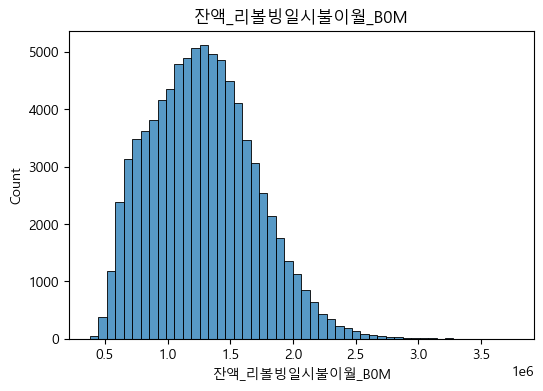

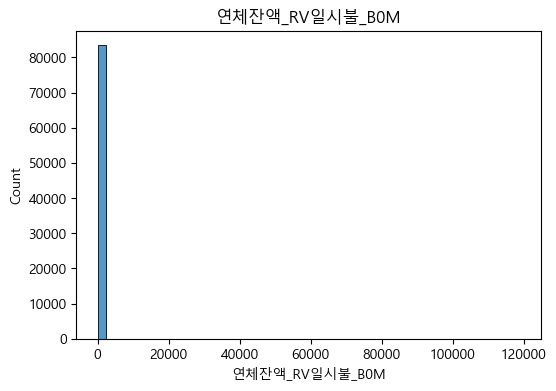

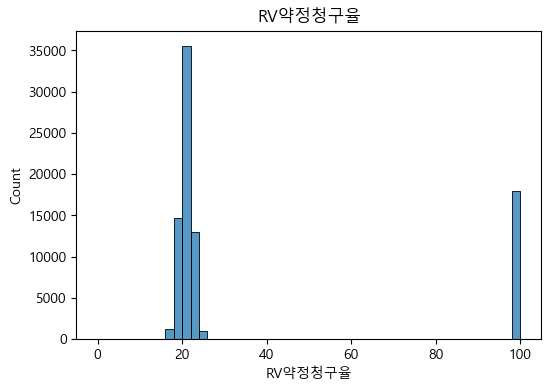

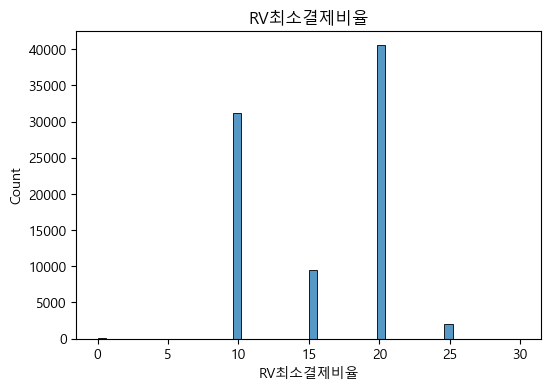

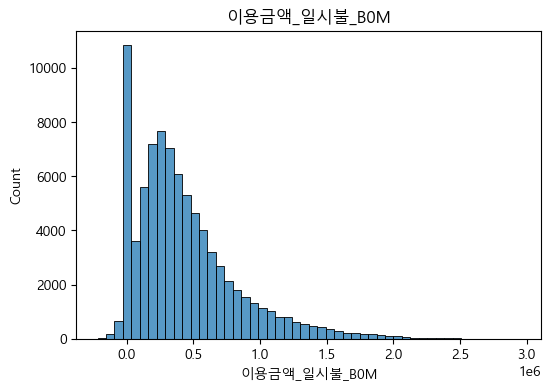

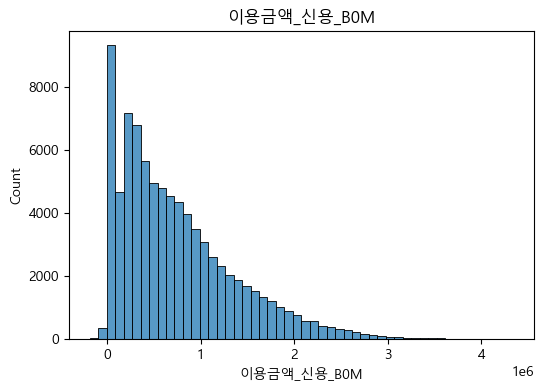

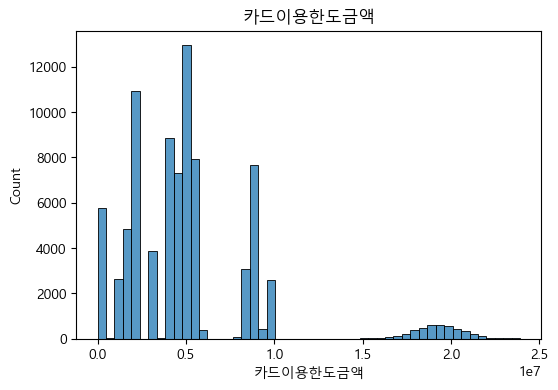

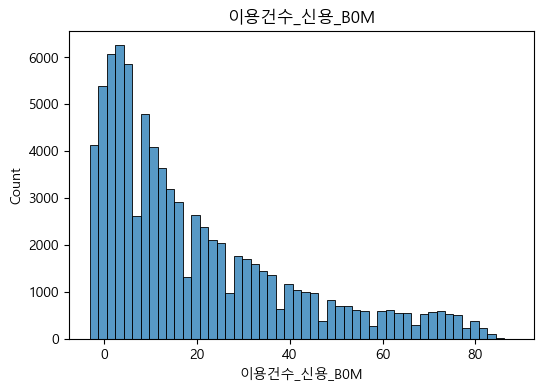

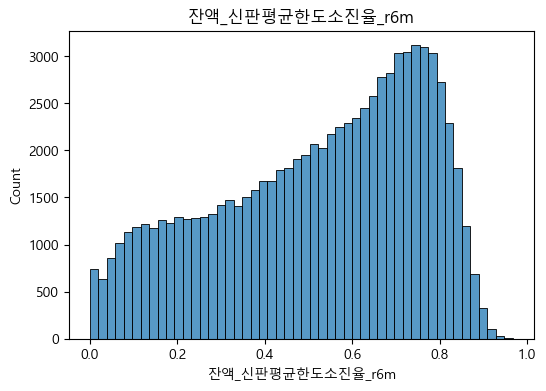

In [37]:
#히스토그램

for c in cols:
    plt.figure(figsize=(6,4))
    sns.histplot(df_analysis[c].dropna(), bins=50)
    plt.title(c)
    plt.show()

#1e6 = 1,000,000


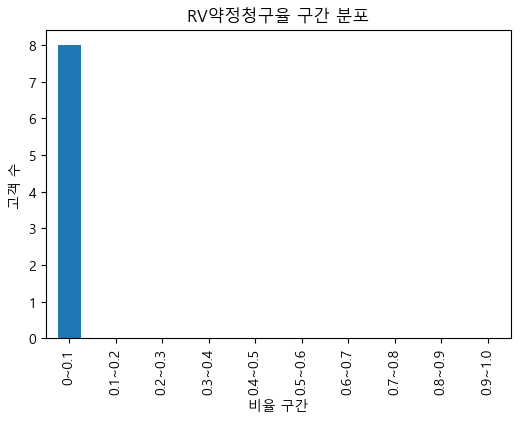

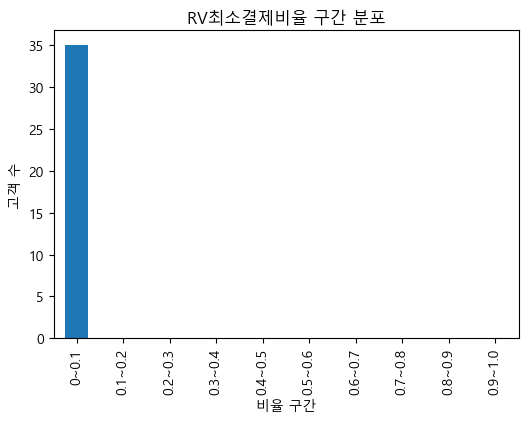

In [48]:
#약정 비율 분포

bins = [0, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1.0]
labels = ['0~0.1','0.1~0.2','0.2~0.3','0.3~0.4','0.4~0.5',
          '0.5~0.6','0.6~0.7','0.7~0.8','0.8~0.9','0.9~1.0']

for c in ['RV약정청구율', 'RV최소결제비율']:
    plt.figure(figsize=(6,4))
    binned = pd.cut(df_analysis[c], bins=bins, labels=labels, include_lowest=True)
    binned.value_counts().reindex(labels).plot(kind='bar')
    plt.title(f'{c} 구간 분포')
    plt.xlabel('비율 구간')
    plt.ylabel('고객 수')
    plt.show()



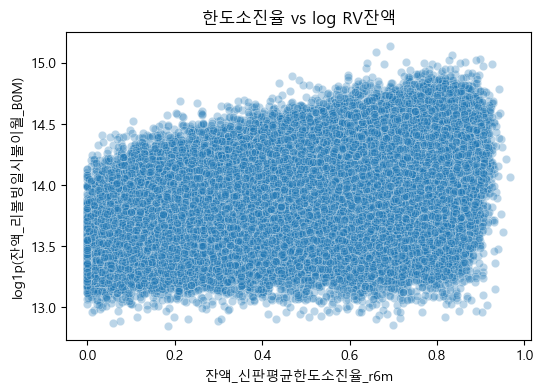

In [39]:
#한도소진율 VS RV잔액

plt.figure(figsize=(6,4))
sns.scatterplot(
    x='잔액_신판평균한도소진율_r6m',
    y=np.log1p(df_analysis['잔액_리볼빙일시불이월_B0M']),
    data=df_analysis, alpha=0.3
)
plt.title('한도소진율 vs log RV잔액')
plt.xlabel('잔액_신판평균한도소진율_r6m')
plt.ylabel('log1p(잔액_리볼빙일시불이월_B0M)')
plt.show()


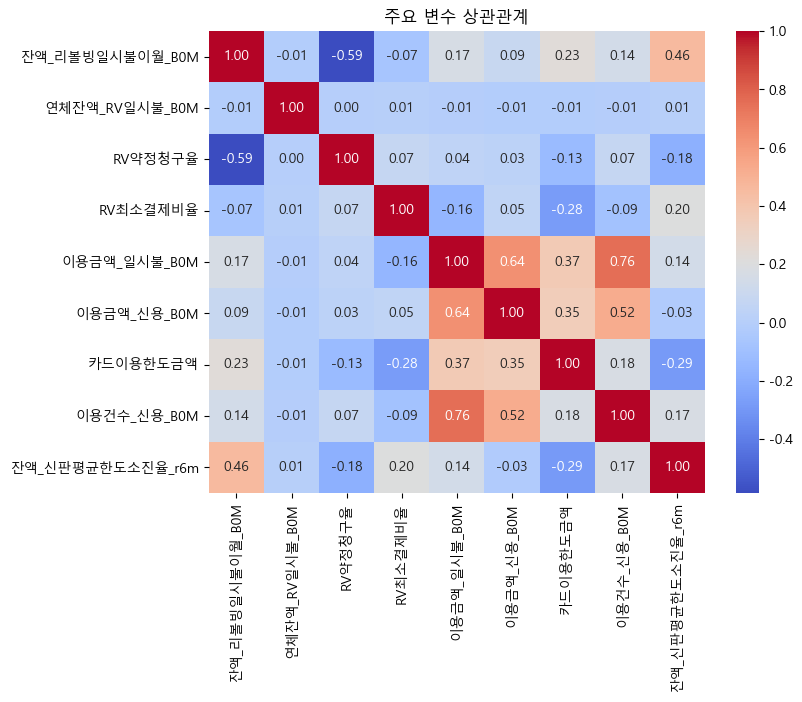

In [40]:
#상관관계

corr = df_analysis.corr(numeric_only=True)
plt.figure(figsize=(8,6))
sns.heatmap(corr, annot=True, fmt=".2f", cmap='coolwarm')
plt.title('주요 변수 상관관계')
plt.show()

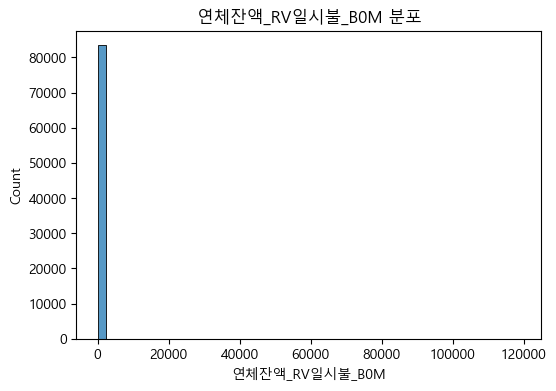

In [41]:
#연체잔액 분포

plt.figure(figsize=(6,4))
sns.histplot(df_analysis['연체잔액_RV일시불_B0M'], bins=50)
plt.title('연체잔액_RV일시불_B0M 분포')
plt.show()

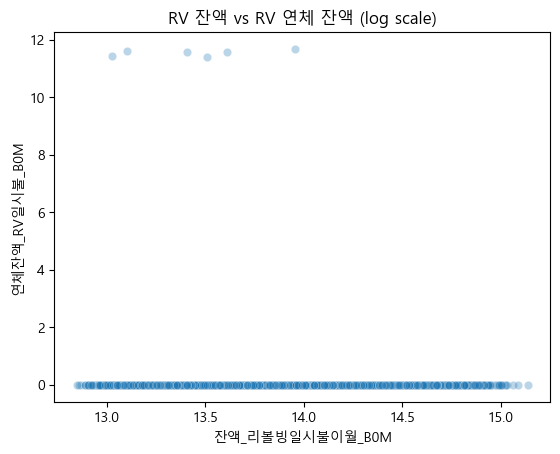

In [42]:
#RV잔액과의 관계

sns.scatterplot(
    x=np.log1p(df_analysis['잔액_리볼빙일시불이월_B0M']),
    y=np.log1p(df_analysis['연체잔액_RV일시불_B0M']),
    alpha=0.3
)
plt.title('RV 잔액 vs RV 연체 잔액 (log scale)')
plt.show()

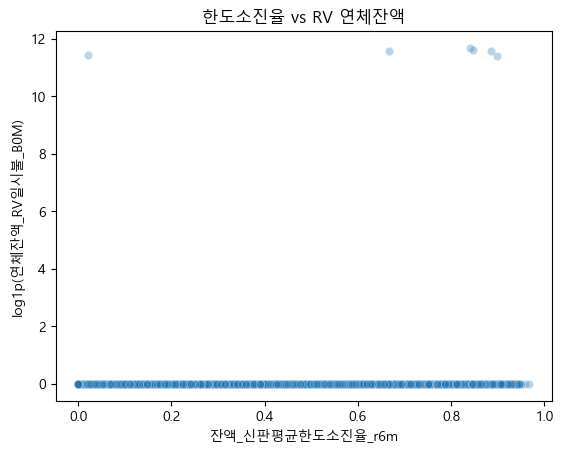

In [49]:
#한도소진율과의 관계

sns.scatterplot(
    data=df_analysis,
    x='잔액_신판평균한도소진율_r6m',
    y=np.log1p(df_analysis['연체잔액_RV일시불_B0M']),
    alpha=0.3
)
plt.title('한도소진율 vs RV 연체잔액')
plt.xlabel('잔액_신판평균한도소진율_r6m')
plt.ylabel('log1p(연체잔액_RV일시불_B0M)')
plt.show()


### 의미 있는 그림 : 히스토그램, 히트맵 ?

### 3. 타겟 변수 분석 방법

In [52]:
df_110 = pd.read_csv("data/01.카드_회원정보/201810_회원정보.csv")
df_410 = pd.read_csv("data/04.카드_청구정보/201810_청구정보.csv")
df_610 = pd.read_csv("data/06.카드_채널정보/201810_채널정보.csv")
df_710 = pd.read_csv("data/07.카드_마케팅정보/201810_마케팅정보.csv")

In [76]:
dfs = {
    110: df_110,
    210: df_210,
    310: df_310,
    410: df_410,
    510: df_510,
    610: df_610,
    710: df_710,
    810: df_810,
}

for key, df in dfs.items():
    print(f"===== df_{key} columns =====")
    print(df.columns)
    print()

    

===== df_110 columns =====
Index(['기준년월', '발급회원번호', '남녀구분코드', '연령', 'VIP등급코드', '최상위카드등급코드', '회원여부_이용가능',
       '회원여부_이용가능_CA', '회원여부_이용가능_카드론', '소지여부_신용', '소지카드수_유효_신용',
       '소지카드수_이용가능_신용', '입회일자_신용', '입회경과개월수_신용', '회원여부_연체', '이용거절여부_카드론',
       '동의여부_한도증액안내', '수신거부여부_TM', '수신거부여부_DM', '수신거부여부_메일', '수신거부여부_SMS',
       '가입통신회사코드', '탈회횟수_누적', '최종탈회후경과월', '탈회횟수_발급6개월이내', '탈회횟수_발급1년이내',
       '거주시도명', '직장시도명', '마케팅동의여부', '유효카드수_신용체크', '유효카드수_신용', '유효카드수_신용_가족',
       '유효카드수_체크', '유효카드수_체크_가족', '이용가능카드수_신용체크', '이용가능카드수_신용',
       '이용가능카드수_신용_가족', '이용가능카드수_체크', '이용가능카드수_체크_가족', '이용카드수_신용체크',
       '이용카드수_신용', '이용카드수_신용_가족', '이용카드수_체크', '이용카드수_체크_가족', '이용금액_R3M_신용체크',
       '이용금액_R3M_신용', '이용금액_R3M_신용_가족', '이용금액_R3M_체크', '이용금액_R3M_체크_가족',
       '_1순위카드이용금액', '_1순위카드이용건수', '_1순위신용체크구분', '_2순위카드이용금액', '_2순위카드이용건수',
       '_2순위신용체크구분', '최종유효년월_신용_이용가능', '최종유효년월_신용_이용', '최종카드발급일자',
       '보유여부_해외겸용_본인', '이용가능여부_해외겸용_본인', '이용여부_3M_해외겸용_본인', '보유여부_해외겸용_신용_본인',
       '이용가능여부_해외겸용_신용_

In [ ]:
# 1) df_510 (잔액정보) – “RV 상태 + 과거 연체 히스토리” 

# 잔액_리볼빙일시불이월_B0M
# → 10월 기준 RV 이월 잔액(원금).
# → 잔액이 클수록 11월에도 연체잔액이 발생/증가할 확률↑

# 연체잔액_RV일시불_과거 데이터 -> 없음
# → 10월 및 과거 개월의 연체잔액 히스토리.
# → 직전/과거 연체 경험 자체가 강력한 predictor.

# 연체건수_R3M / R6M 같은 계열
# → 최근 3/6개월 동안 몇 번 연체했는지.
# → “연체 습관”을 잡는 변수.

# RV잔액이월횟수_R3M,R6M
# → 최근 6개월 동안 RV를 얼마나 자주 썼는지(이월 횟수).
# → RV를 상시 쓰는 사람 vs 가끔 쓰는 사람 구분.


# 요약:
# “지금 RV 잔액이 얼마나 큰지 + 과거에 RV 연체/사용 패턴이 어떤지” 파악


In [ ]:
# 2) df_210 (신용정보) – “약정 조건 + 한도”

# RV약정청구율

# RV최소결제비율

# → 고객이 설정한 상환 의지 / 카드사가 부과하는 부담
# : 약정 비율 낮을수록 월 상환액 작고, 잔액을 오래 끌고 갈 가능성↑ → 연체 위험↑

# 카드이용한도금액
# → 절대 한도가 낮은데 사용이 많으면 리스크↑
# → 파생변수 : 한도와 이용금액/잔액을 비율로 봐도 좋을 듯.

# 추가로 df_210에 신용등급·연체등급 같은 게 있으면 무조건 포함.

In [ ]:
# 3) df_310 (승인·이용 정보) – “소비 패턴”

# 이용금액_일시불_B0M
# → 10월에 새로 쓴 일시불 금액.
# → RV로 전환될 가능성이 크고, 11월 청구 부담을 만든다.

# 이용금액_신용_B0M
# → 전체(일시불+할부+현금서비스) 신용 이용 금액.
# → 카드 전반의 부채 부하를 보여주는 척도.

# 이용건수_신용_B0M
# → 거래 횟수 – “소액 다건형 vs 소수 대금액형”.

# 이용금액_R3M_신용채크, 이용금액_R3M_신용
# → 최근 3개월 누적/평균 사용량.


# 일시불이용_대비_RV잔액비율 = 잔액_리볼빙일시불이월_B0M / (이용금액_일시불_B0M + 1)

# 신용이용률 = 이용금액_신용_B0M / 카드이용한도금액

In [ ]:
# 4) df_810 (성과정보) – “한도소진율 + 잔액 추세”

# 잔액_신판평균한도소진율_r6m
# → 최근 6개월 한도소진율 평균.
# → 이미 한도를 쥐어짜고 있는 고객인지.

# 잔액_신판최대한도소진율_r3m, 잔액_신판잔액증가율_r3m 등
# → 최근에 한도소진율이 확 올라갔는지.

# 변동률_RV잔액_r3m 같은 계열
# → RV잔액이 최근에 급증했는지(잔액 증가 속도).

# 이 블록은 **“장기간 쥐어짜는 타입 vs 최근에 갑자기 악화된 타입”**을 구분하는데 용이

In [ ]:
# df_110:

# 연령대, 성별, 회원등급, VIP등급, Life_Stage

# 연령대·소득수준·등급별로 연체 위험이 다를 것이라는 가설.


# df_610:

# 인입콜수_ARS_R6M, 모바일앱_로그인횟수_R3M 등

# 자주 앱/콜센터 보는 사람은 관리 의지가 강한 편일 수 있음.


# df_710:

# TM접촉횟수_R3M, TM수락횟수 등

# TM 대상이 되는 것 자체가 “이미 리스크 높게 본 고객”일 수도 있음.

# 이건 보조 피처 느낌이고, 필수는 아니지만 있으면 모델 성능이 조금 오를 수 있는 애들.

### 타겟 변수 분석이 아직 마무리가 안돼서, 이후 내용을 추가해서 라이브 스터디 때 참여하겠습니다.